In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hapi import *
db_begin('data');

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [3]:
getHelp(profiles)

Profiles available:
  HT        : PROFILE_HT
  SDRautian : PROFILE_SDRAUTIAN
  Rautian   : PROFILE_RAUTIAN
  SDVoigt   : PROFILE_SDVOIGT
  Voigt     : PROFILE_VOIGT
  Lorentz   : PROFILE_LORENTZ
  Doppler   : PROFILE_DOPPLER


In [9]:
# max_wavenumber = 1./(0.5e-6*1e2) # convert 0.5 microns to cm^{-1}
max_wavenumber = 1./(0.85e-6*1e2) # convert 0.5 microns to cm^{-1}
min_wavenumber = 1./(0.95e-6*1e2) # convert 0.5 microns to cm^{-1}
print(min_wavenumber, max_wavenumber)

# fetch('H2O',1,1,min_wavenumber,max_wavenumber);
nu,coef = absorptionCoefficient_Voigt(SourceTables='H2O', Diluent={'CO2':1.0}, );

# fetch('H2O',2,1,2000,2100)
# nu,coef = absorptionCoefficient_Lorentz(SourceTables='H2O', Diluent={'air':1.0})

10526.315789473683 11764.70588235294

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  655

0.905 1.185403580507758e-08
0.9400000000000001 2.5330879228536527e-10


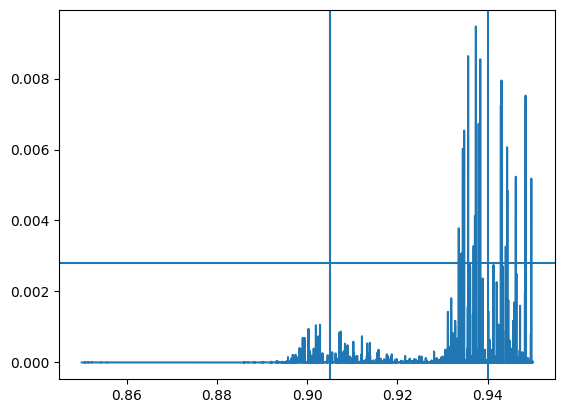

In [23]:
max_wavenumber = 1./(0.85e-6*1e2) # convert 0.5 microns to cm^{-1}
min_wavenumber = 1./(0.95e-6*1e2) # convert 0.5 microns to cm^{-1}
wavenumber_step = 0.01
T = 215. # K
P = 0.006

# fetch('H2O',1,1,min_wavenumber,max_wavenumber);

# nu, coef = absorptionCoefficient_Voigt(
#     SourceTables='H2O', 
#     WavenumberRange=(min_wavenumber, max_wavenumber),
#     Environment={'T': T, 'p': P},
#     HITRAN_units=True   
# )

# Convert to m^2/molec
# coef *= 1e-4

Mars_density = 0.02/7.3080318e-26 # 1/m^3
water_fraction = 0.0003
water_number_density = Mars_density*water_fraction
altitude = 40. # m
water_optical_depth = water_number_density*altitude*coef

lamb = (1/nu/1e2)/1e-6
plt.plot(lamb, water_optical_depth)

# Wavelengths from https://gemini.google.com/share/f1763edbeddb
v3HP_lamb = 905.e-9/1e-6
v4_lamb = 940.e-9/1e-6
plt.axvline(v3HP_lamb)
plt.axvline(v4_lamb)
# plt.axvline(1.064)

mn_ind = np.argmin(np.abs(v3HP_lamb - lamb))
print(v3HP_lamb, water_optical_depth[mn_ind])

mn_ind = np.argmin(np.abs(v4_lamb - lamb))
print(v4_lamb, water_optical_depth[mn_ind])

# Dust optical depth - https://pdf.sciencedirectassets.com/272593/1-s2.0-S0019103513X00041/1-s2.0-S0019103513000353/main.pdf
dust_extinction = 0.07/1e3 # per meter
dust_optical_depth = dust_extinction*altitude
# print(dust_optical_depth)
plt.axhline(dust_optical_depth)

# print(coef)

Using data

H2O
                     Lines parsed: 1036
CO2
                     Lines parsed: 3769

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
Header written to data/H2O.header
END DOWNLOAD
                     Lines parsed: 1036
PROCESSED
{'air': 1.0}
0.594633 seconds elapsed for abscoef; nlines = 1036


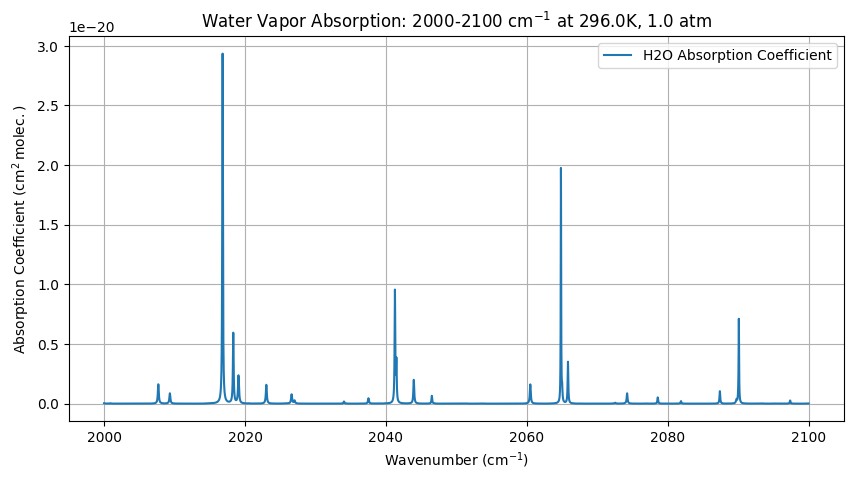

In [6]:
# from hapi import *

# help(absorptionCoefficient_Voigt)

# 1. Initialize the local database folder
# This will create a 'data' folder in your directory
# db_begin('data')

# 2. Download water vapor (Molecule ID 1) data from HITRAN
# We fetch a slightly wider range to account for line-wing contributions
# Molecule number and isotopologue number shown on p. 52 - https://hitran.org/static/hapi/hapi_manual.pdf

fetch('H2O', 1, 1, 1990, 2110)

# 3. Define the calculation parameters
# Wavenumber step of 0.01 provides high resolution
wavenumber_step = 0.01 
w_min, w_max = 2000, 2100

# Specify environment: Temperature (Kelvin) and Pressure (Atmospheres)
T = 296.0  # Standard temperature
P = 1.0    # Standard pressure

# 4. Calculate the Absorption Coefficient
# 'absorptionCoefficient_Voigt' returns (wavenumbers, coefficients)
nu, coef = absorptionCoefficient_Voigt(
    SourceTables='H2O', 
    WavenumberRange=(w_min, w_max),
    WavenumberStep=wavenumber_step,
    Environment={'T': T, 'p': P},
    HITRAN_units=True   
)

# Optional: Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(nu, coef, label='H2O Absorption Coefficient')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel(r'Absorption Coefficient (${\rm cm^{2}\, molec.}$)')
plt.title(f'Water Vapor Absorption: {w_min}-{w_max} cm$^{{-1}}$ at {T}K, {P} atm')
plt.grid(True)
plt.legend()
plt.show()